# 01 ViewRawData — PalletLogs

Notebook นี้ใช้สำหรับดูข้อมูลเบื้องต้นของ `PalletLogs.csv`

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

## การโหลดข้อมูล

โหลดไฟล์ข้อมูลจาก `PalletLogs.csv`

In [2]:
source_path = '../../data/raw/PalletLogs.csv'
df = pd.read_csv(source_path, encoding='utf-8-sig')

print(f'source: {source_path}')
print(f'rows: {df.shape[0]:,}')
print(f'columns: {df.shape[1]:,}')
df.head()

source: ../../data/raw/PalletLogs.csv
rows: 399,233
columns: 31


,PalletID,Action,PalletStatus,PackSize,Amount,LotNo,MaterialCode,NameThai,ProductType,Model,...,FromFloorNo,ToLocationType,ToLocationCode,ToLocationName,ToRowNo,ToColNo,ToFloorNo,UserCreate,UserCreateCode,PlantCode
0,SB1LR260511450,POSTTOCHECKERLOCATION,FOLKPOSTEND,0,0,NaN,NaN,NaN,NaN,NaN,...,0,POSTLOCATION,COM22090001,SB1-1ลานโอน,NaN,0,0,&#3616;&#3588;&#3623;&#3633;&#3605; &#3648;&#3...,2503000002,NaN
1,SB1LR260511451,POSTTOCHECKERLOCATION,FOLKPOSTEND,0,0,NaN,NaN,NaN,NaN,NaN,...,0,POSTLOCATION,COM23110002,ลานจ่าย3 ช่องจ่าย 2 (ครอบ),NaN,0,0,&#3616;&#3588;&#3623;&#3633;&#3605; &#3648;&#3...,2503000002,NaN
2,SB1-1LS3690515P025,POSTTOCHECKERLOCATION,FOLKPOSTEND,320,320,3690515P,ZCB10STDA002000A14,ก/บ คอนกรีตSCGเอลาบานา สีน้ำตาลโอ๊คแดง,CPAC-Tile,CPAC,...,1,POSTLOCATION,PL20100001,ลานจ่าย 1 ช่องจ่าย 1 (CPAC),NaN,0,0,ชัยณรงค์ เพ็ชรนิล,2102000002,NaN
3,SB1LR260511214,POSTTOCHECKERLOCATION,FOLKPOSTEND,0,0,NaN,NaN,NaN,NaN,NaN,...,0,POSTLOCATION,COM23110003,อุปกรณ์,NaN,0,0,เสน่ห์ แสงตระกอน,2202000004,NaN
4,NaN,POSTTOCHECKERLOCATION,NaN,0,0,NaN,NaN,NaN,NaN,NaN,...,0,POSTLOCATION,PL20100001,ลานจ่าย 1 ช่องจ่าย 1 (CPAC),NaN,0,0,ชัยณรงค์ เพ็ชรนิล,2102000002,NaN


## Data Type และขนาดข้อมูล

ดูจำนวนแถว, จำนวนคอลัมน์, และชนิดข้อมูลของแต่ละคอลัมน์

In [3]:
dtype_summary = pd.DataFrame(
    {
        'column': df.columns,
        'dtype': df.dtypes.astype(str).values,
    }
)

dtype_summary.sort_values(['dtype', 'column']).reset_index(drop=True)

,column,dtype
0,Color,float64
1,FromRowNo,float64
2,PlantCode,float64
3,ToRowNo,float64
4,Amount,int64
5,FromColNo,int64
6,FromFloorNo,int64
7,PackSize,int64
8,ToColNo,int64
9,ToFloorNo,int64


## Missing Values

สรุปคอลัมน์ที่มีค่าว่าง โดยนับรวมค่า `NULL` เป็น missing

In [4]:
null_like_tokens = ['NULL', '', 'nan', 'NaN', 'None']
df_profile = df.replace(null_like_tokens, np.nan)

missing_summary = pd.DataFrame(
    {
        'column': df_profile.columns,
        'missing_count': df_profile.isna().sum().values,
        'missing_pct': (df_profile.isna().mean() * 100).round(2).values,
    }
)

missing_summary = missing_summary.loc[missing_summary['missing_count'] > 0].copy()
missing_summary = missing_summary.sort_values('missing_count', ascending=False).reset_index(drop=True)
missing_summary

,column,missing_count,missing_pct
0,ToRowNo,399233,100.00
1,Color,399233,100.00
2,PlantCode,399233,100.00
3,Coat,150673,37.74
4,ProductClass,133839,33.52
5,Curve,120296,30.13
6,FromLocationName,90132,22.58
7,FromRowNo,90132,22.58
8,FromLocationCode,90132,22.58
9,LotNo,89388,22.39


## Unique Values ของ Categorical Columns

ดูการกระจายของคอลัมน์ที่เป็น category

In [5]:
cat_cols = [
    'Action', 'PalletStatus', 'ProductType', 'ProductClass',
    'FromLocationType', 'ToLocationType', 'Coat', 'Curve'
]

for col in cat_cols:
    if col in df.columns:
        print(f'\n{col}:')
        print(df[col].value_counts(dropna=False).head(10))


Action:
Action
POSTTOCHECKERLOCATION    399233
Name: count, dtype: int64

PalletStatus:
PalletStatus
FOLKPOSTEND      351685
NaN               47286
POSTCOMPLETED       218
GOOD                 42
PACK                  2
Name: count, dtype: int64

ProductType:
ProductType
CPAC-Tile           154473
PRESTIGE-Tile       151380
NaN                  81486
CPAC-Fitting          6781
PRESTIGE-Fitting      3812
ACCESSORIES           1146
DURA-Fitting           155
Name: count, dtype: int64

ProductClass:
ProductClass
A      169193
NaN    133839
MTO     54853
B       41348
Name: count, dtype: int64

FromLocationType:
FromLocationType
NORMAL          278397
PALLETSOURCE     90132
BUFFER           30686
FRACTION            17
NaN                  1
Name: count, dtype: int64

ToLocationType:
ToLocationType
POSTLOCATION    399233
Name: count, dtype: int64

Coat:
Coat
Pigmented GEP    166630
NaN              150673
X-Shield          71053
Clear GEP         10877
Name: count, dtype: int64

Curve:
C

## Numeric Columns

สถิติเบื้องต้นของคอลัมน์ตัวเลข

In [6]:
df[['PackSize', 'Amount', 'FromColNo', 'FromFloorNo', 'ToColNo', 'ToFloorNo']].describe()

,PackSize,Amount,FromColNo,FromFloorNo,ToColNo,ToFloorNo
count,399233.000000,399233.000000,399233.000000,399233.000000,399233.0,399233.0
mean,170.685209,171.669859,11.974887,1.477851,0.0,0.0
std,97.439464,96.280195,13.325862,1.090470,0.0,0.0
min,0.000000,0.000000,0.000000,0.000000,0.0,0.0
25%,180.000000,180.000000,1.000000,1.000000,0.0,0.0
50%,180.000000,180.000000,9.000000,1.000000,0.0,0.0
75%,240.000000,240.000000,20.000000,2.000000,0.0,0.0
max,320.000000,320.000000,363.000000,8.000000,0.0,0.0


## StampDateTime

ดูรูปแบบและช่วงเวลาของ `StampDateTime`

earliest : 2025-01-02 07:30:08
latest   : 2026-05-18 10:54:28
parse fail: 0


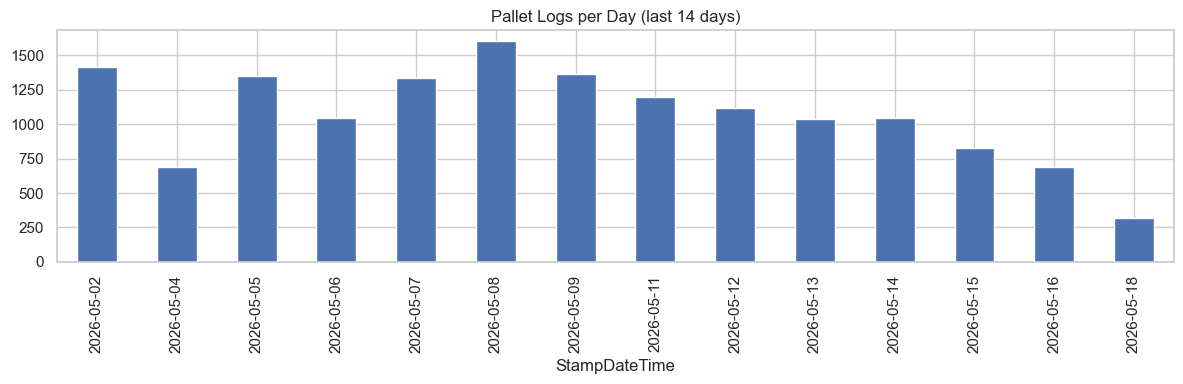

In [7]:
stamp = pd.to_datetime(df['StampDateTime'], format='%d/%m/%Y %H:%M:%S', errors='coerce')

print(f'earliest : {stamp.min()}')
print(f'latest   : {stamp.max()}')
print(f'parse fail: {stamp.isna().sum():,}')

stamp.dt.date.value_counts().sort_index().tail(14).plot(
    kind='bar', figsize=(12, 4), title='Pallet Logs per Day (last 14 days)'
)
plt.tight_layout()
plt.show()

## Location Overview

ดู FromLocation และ ToLocation ที่พบบ่อย

In [8]:
print('=== FromLocationName top 10 ===')
print(df['FromLocationName'].value_counts(dropna=False).head(10))

print('\n=== ToLocationName top 10 ===')
print(df['ToLocationName'].value_counts(dropna=False).head(10))

=== FromLocationName top 10 ===
FromLocationName
NaN            90132
BB-01 C0 F0     2145
BB-02 C0 F0     1662
BB-03 C0 F0      688
BB-05 C0 F0      473
BB-06 C0 F0      250
BB-13 C0 F0      225
BB-08 C0 F0      131
BB-07 C0 F0      108
BB-04 C0 F0       82
Name: count, dtype: int64

=== ToLocationName top 10 ===
ToLocationName
ลานจ่าย3 ช่องจ่าย 2 (ครอบ)         89848
ลานจ่าย3 ช่องจ่าย 1 (ครอบ)         67449
ลานจ่าย 2 ช่องจ่าย 3 (Prestige)    64304
ลานจ่าย 1 ช่องจ่าย 1 (CPAC)        60417
ลานจ่าย 2 ช่องจ่าย 2 (Prestige)    46617
ลานจ่าย 2 ช่องจ่าย 1 (Prestige)    30612
ลานจ่าย 1 ช่องจ่าย 2 (CPAC)        30353
ลานจ่าย 1 ช่องจ่าย 3 (CPAC)         4451
อุปกรณ์                             3797
SB1-1ลานโอน                         1384
Name: count, dtype: int64


## Product Distribution

สัดส่วน ProductType และ ProductClass

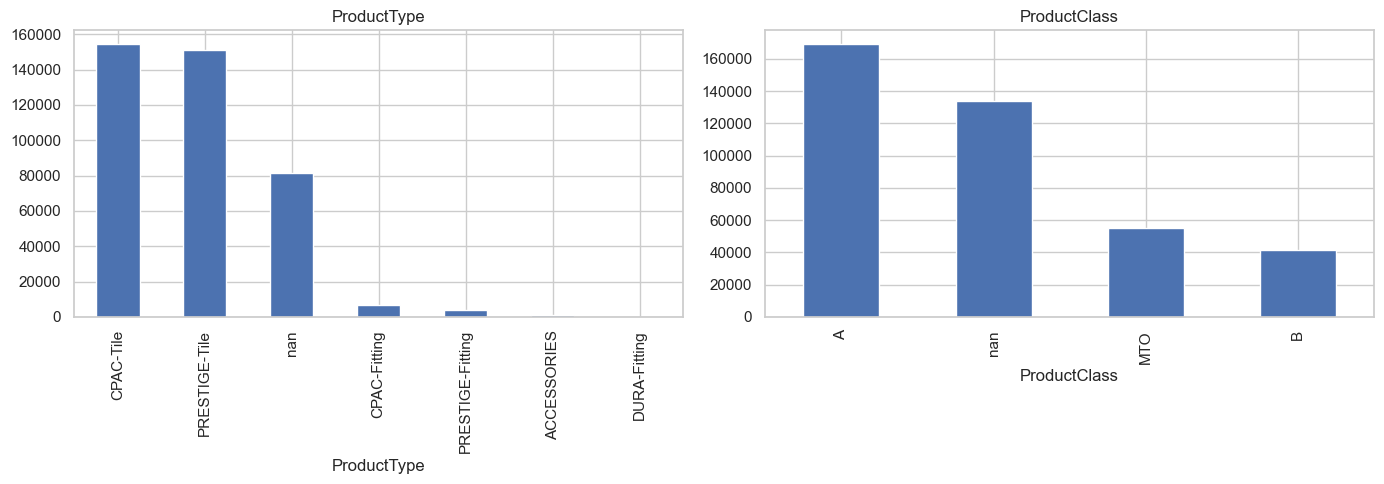

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['ProductType'].value_counts(dropna=False).head(8).plot(
    kind='bar', ax=axes[0], title='ProductType'
)
df['ProductClass'].value_counts(dropna=False).plot(
    kind='bar', ax=axes[1], title='ProductClass'
)

plt.tight_layout()
plt.show()